# ASTR 457: Foundations of Data Science in Astronomy

**Fall 2026, University of Illinois Urbana-Champaign**

Prof. Gautham Narayan | TA: Abha Vishwakarma

Thu Sep 17, 2026 - Day 8: Model comparison and goodness of fit

<img src="images/uiuc_logo.png" alt="University of Illinois Urbana-Champaign wordmark" width="220" style="display:block;margin:0 auto;">


## Today's plan

* Recap: Tuesday's numerical MLE fit and its nuisance parameter
* A double-peaked line in NGC 1097, why a rotating disk makes two peaks, and a second one from the SDSS we fit in class
* Is the model even right? $\chi^2$ and its distribution, the residuals, the QQ-plot, and a transit fit diagnosed by its reduced $\chi^2$
* More parameters always fit better (if the models are nested): von Neumann's elephant, and Occam's razor
* Nested models: the likelihood-ratio test. Any two models: AIC and BIC
* In-class exercise, in pairs, Copilot allowed: a second line, and you decide
* EXTRA notebook, for reading: Fisher forecasts in practice, `lecture/04/extra_fisher_in_practice.ipynb`


In [1]:
# Presenter setup (a RISE "skip" cell: it runs, but is not a slide).
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize
from scipy import stats

# A real double-peaked broad H-alpha line: SDSS J142754.77+635448.4 (Strateva et al. 2003, AJ 126, 1720, Table 1),
# SDSS DR17 plate-mjd-fiber 499-51988-157, de-redshifted with the pipeline z = 0.146, rest wavelengths in air.
# Provenance and the vacuum-to-air conversion are in the header of the CSV.
with open('data/sdss_double_peaked_halpha.csv') as _f:
    _nhead = sum(1 for _line in _f if _line.startswith('#'))
_d = np.genfromtxt('data/sdss_double_peaked_halpha.csv', delimiter=',', skip_header=_nhead, names=True)
wave_all, flux_raw, err_raw = _d['wave_rest_A'], _d['flux'], _d['flux_err']

# continuum: a weighted straight line through the line-free windows, divided out (errors propagated)
_cw = ((wave_all > 6200) & (wave_all < 6350)) | ((wave_all > 6750) & (wave_all < 6900))
_A = np.vstack([np.ones(_cw.sum()), wave_all[_cw] - 6550]).T * (1 / err_raw[_cw])[:, None]
_coef, *_ = np.linalg.lstsq(_A, flux_raw[_cw] / err_raw[_cw], rcond=None)
_cov = np.linalg.inv(_A.T @ _A)
continuum = _coef[0] + _coef[1] * (wave_all - 6550)
_cont_err = np.sqrt(_cov[0, 0] + _cov[1, 1] * (wave_all - 6550)**2 + 2 * _cov[0, 1] * (wave_all - 6550))
flux_all = flux_raw / continuum
err_all = flux_all * np.sqrt((err_raw / flux_raw)**2 + (_cont_err / continuum)**2)

# mask the narrow lines from the host galaxy (+/- 8 A): the broad line is the question, not these
narrow_lines = [6548.0, 6562.8, 6583.5, 6716.4, 6730.8]
use = np.ones_like(wave_all, dtype=bool)
for _l in narrow_lines:
    use &= ~((wave_all > _l - 8) & (wave_all < _l + 8))
wave, flux_obs, noise = wave_all[use], flux_all[use], err_all[use]
n_data = wave.size

def gauss(x, amp, cen, wid):
    return amp * np.exp(-0.5 * ((x - cen) / wid)**2)
print(f"{wave_all.size} pixels in 6200-6900 A, {n_data} used after masking the narrow lines; median error {np.median(noise):.3f} of the continuum")


464 pixels in 6200-6900 A, 412 used after masking the narrow lines; median error 0.027 of the continuum


## Recap

* real fits usually have no closed-form MLE: we minimize $-2\ln\mathcal{L}$ numerically, same idea as $\chi^2$
* nuisance parameters (Tuesday's intrinsic scatter) have to be fit even when we never report them
* an optimizer reports where it stopped. It cannot promise there is no better valley
* Day 5/6's six-night sinusoid, recalled Tuesday: more starting points can still miss; the fix is more data, or sampling the whole likelihood instead of hunting for its minimum (MCMC, Oct 1)
* today: once the fit converges, is the model even right? And how do you compare two of them?


In [2]:
# Visual reminder: Tuesday's Cepheid fit, with its nuisance parameter (a "skip" cell: runs, not a slide)
import csv
with open('data/aavso_cepheids_pl.csv') as f:
    _cep = list(csv.DictReader(f))
logP = np.array([np.log10(float(c['period_days'])) for c in _cep])
M_obs = np.array([float(c['M_V']) for c in _cep])
sigma_obs = np.full(len(_cep), 0.06)

def neg2logL(theta):
    a, b, log_sig_int = theta
    sig_int = np.exp(log_sig_int)
    var = sigma_obs**2 + sig_int**2
    resid = M_obs - (a * logP + b)
    return np.sum(resid**2 / var + np.log(var))

_res = minimize(neg2logL, x0=[-2.0, -1.0, np.log(0.3)], method='Nelder-Mead',
                options={'xatol': 1e-8, 'fatol': 1e-8, 'maxiter': 5000})
a_hat, b_hat, sig_int_hat = _res.x[0], _res.x[1], np.exp(_res.x[2])
a_lit, b_lit = -2.43, -1.62   # Benedict et al. 2007, converted to M = a logP + b

def plot_recap_cepheids():
    fig, ax = plt.subplots(figsize=(6, 2.8))
    xx = np.linspace(logP.min() - 0.05, logP.max() + 0.05, 50)
    ax.fill_between(xx, a_hat * xx + b_hat - sig_int_hat, a_hat * xx + b_hat + sig_int_hat,
                    color='C3', alpha=0.15, label=fr'$\pm\hat\sigma_\mathrm{{int}}$ = {sig_int_hat:.2f} mag')
    ax.plot(xx, a_hat * xx + b_hat, 'C3', lw=1.5, label=fr'numerical MLE: a = {a_hat:.2f}, b = {b_hat:.2f}')
    ax.plot(xx, a_lit * xx + b_lit, color='0.4', ls='--', lw=1.2, label='Benedict et al. 2007')
    ax.errorbar(logP, M_obs, yerr=sigma_obs, fmt='o', color='C0', ms=4, capsize=2)
    ax.invert_yaxis()
    ax.set_xlabel(r'$\log_{10} P$ [days]')
    ax.set_ylabel(r'$M_V$')
    ax.legend(fontsize=8, loc='upper right')
    plt.tight_layout()
    plt.show()


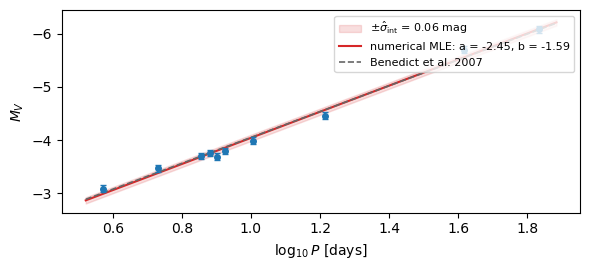

In [3]:
# Tuesday's fit: the MLE line sits on the literature line; the band is the intrinsic scatter (about the size of the error bars, by coincidence)
plot_recap_cepheids()


## Double-peaked H$\alpha$ in NGC 1097

<table style="border:none; margin:0 auto;"><tr style="border:none;"><td style="border:none; padding:4px; vertical-align:top;"><img src="images/schimoia2012_fig2_ngc1097_halpha_doublepeak.png" alt="Optical spectrum of the active galaxy NGC 1097 from 4750 to 7200 angstroms, drawn as three vertically offset traces on one axis: the raw nuclear spectrum on top, the stellar-population template in the middle, and at the bottom the difference, in which a broad double-peaked emission line stands out at H-alpha" height="360" style="display:block;margin:0 auto;"></td><td style="border:none; padding:4px; vertical-align:top;"><img src="images/schimoia2012_fig3_ngc1097_halpha_3epochs_crop.png" alt="Three epochs of the continuum-subtracted H-alpha region of NGC 1097, March 2010, August 2010 and December 2010, each showing a broad line split into a blue horn and a red horn on either side of the narrow line at center, with the taller horn changing from red to blue between epochs" height="360" style="display:block;margin:0 auto;"></td></tr></table>

<div style="font-size:0.8em; text-align:center; color:#666;">Schimoia, Storchi-Bergmann, Nemmen, Winge &amp; Eracleous 2012, ApJ 748, 145 (arXiv:1203.6101). Left: Fig. 2, three offset traces on one axis. Right: Fig. 3, three of the six epochs. The figure labels H&alpha; at its vacuum wavelength, 6564 &Aring;; 6562.8 &Aring; is the air value we quote.</div>

* H$\alpha$: the $n = 3 \to 2$ line of hydrogen, 6562.8 &Aring;, the strongest line in most optical emission spectra
* NGC 1097 is a nearby AGN (an active galactic nucleus, a galaxy centre lit by gas falling onto its black hole). Left: subtract the host starlight (middle trace) from the raw nucleus (top) and the line appears (bottom)
* right: the broad H$\alpha$ splits into two peaks, and the taller peak changes from epoch to epoch (a changing-look AGN). Broad-line profiles that change on months: the changing-look AGN Charlotte Ward's group studies; she speaks here next Tuesday
* here the cause is a rotating disk around the black hole (a binary is the other classic cause of a double peak). Same question either way: one velocity component, or two?


## Why a disk makes two peaks

<div style="display:flex; align-items:flex-start; gap:1.2em; margin-top:0.4em;">
<video controls width="520" src="media/blackhole_accretion_disk_nasa_svs_2019.mp4" style="border-radius:4px;"></video>
<div>

* we're looking at gas in Keplerian rotation, $v \propto r^{-1/2}$: the side coming toward us blueshifts, the side going away redshifts
* take one ring, tilted by $i$. Near the two tangent points the line-of-sight velocity barely changes, so lots of gas shares nearly the same Doppler shift: a pile-up at $\pm v(r)\sin i$ (that pile-up is the peak)
* rings at many radii add up: the outer disk sets the peak separation, the inner disk fills the wings
* Doppler boosting brightens the approaching side, so the blue peak is usually the brighter one
* a hot spot or spiral arm breaks the symmetry, and we watch the peak ratio change as it orbits

</div>
</div>

<div style="font-size:0.7em; color:#666;">Left: simulated accretion disk around a black hole, rotating through 360°, the near side brightened by Doppler boosting and the far side lensed into view (NASA's Goddard Space Flight Center/Jeremy Schnittman, SVS #13326; NASA media, free to use with credit). Not in the repository - plays from a local file in class; watch it here: https://svs.gsfc.nasa.gov/13326. Disk-line model: Chen &amp; Halpern 1989, ApJ 344, 115; Eracleous &amp; Halpern 1994, ApJS 90, 1.</div>


## One broad line, or two?

* SDSS J142754.77+635448.4: one of the double-peaked AGN Strateva et al. 2003 pulled out of the SDSS (the Sloan Digital Sky Survey); spectrum from SDSS DR17
* de-redshifted ($z = 0.146$), the continuum divided out, the narrow lines from the host galaxy masked
* every pixel has its own error bar from the SDSS pipeline, a few percent of the continuum
* the same question as NGC 1097: one velocity component, or two?


In [4]:
# The real spectrum, continuum-normalized, with its error bars and the masked narrow-line windows (a "skip" cell)
def plot_spectrum():
    fig, ax = plt.subplots(figsize=(7, 4.2))
    ax.errorbar(wave_all, flux_all, yerr=err_all, fmt='.', color='C0', ms=3, alpha=0.6, elinewidth=0.5)
    for l in narrow_lines:
        ax.axvspan(l - 8, l + 8, color='0.85', zorder=0)
    ax.axhline(1, color='0.5', lw=0.8)
    ax.set_xlabel(r'rest wavelength [$\AA$], air')
    ax.set_ylabel('flux / continuum')
    ax.set_title('SDSS J142754.77+635448.4: one broad line, or two?')
    plt.tight_layout()
    plt.show()


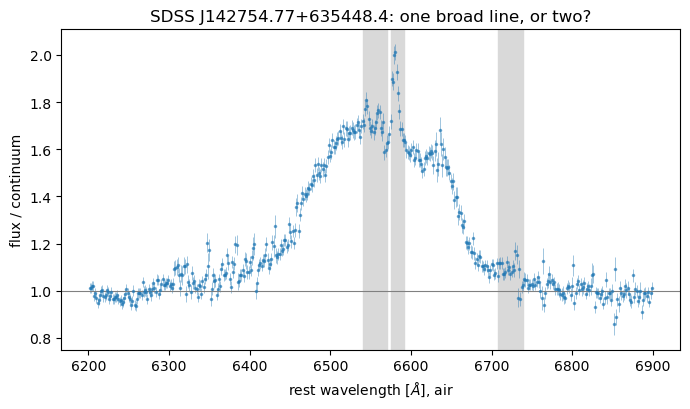

In [5]:
# the broad H-alpha of SDSS J1427+6354; grey bands are the masked narrow lines from the host
plot_spectrum()


* two humps: a broad one peaking near 6520 &Aring; and a sharper one near 6640 &Aring;, about 5500 km/s apart. One line, or two?


## Two models for one line

$G(\lambda; \lambda_0, w) = e^{-(\lambda-\lambda_0)^2/2w^2}$ is a unit-height Gaussian: $A$ is the peak height above the continuum, $\lambda_0$ the center, $w$ the width.

$$\text{Model 1: } f(\lambda) = 1 + A_1\, G(\lambda; \lambda_1, w_1) \qquad (k = 3\text{ free parameters})$$
$$\text{Model 2: } f(\lambda) = 1 + A_1\, G(\lambda; \lambda_1, w_1) + A_2\, G(\lambda; \lambda_2, w_2) \qquad (k = 6)$$

* Model 1 is **nested** inside Model 2: set $A_2 = 0$ and they're identical. We'll need that nesting for the likelihood-ratio test


## $\chi^2$ for both models

* $\chi^2$ as on Day 5/6: each pixel's miss in units of its error bar, squared and summed
* as on Day 2: if the model is right, each term averages 1, so $\chi^2 \approx$ the number of degrees of freedom, dof $= N - k$ (each fitted parameter uses one up)
* i.e. **reduced $\chi^2$** $\equiv \chi^2/\text{dof}$ should come out near 1. Ours come out at 2.7 and 1.9. How near is near? Next slide


In [6]:
# Fit the one-component and two-component models by chi-squared minimization (a "skip" cell).
def chi2_one(p):
    A1, c1, w1 = p
    if A1 < 0 or w1 < 1:
        return 1e30
    model = 1 + gauss(wave, A1, c1, w1)
    return np.sum((flux_obs - model)**2 / noise**2)

def chi2_two(p):
    A1, c1, w1, A2, c2, w2 = p
    if min(A1, A2) < 0 or min(w1, w2) < 1:
        return 1e30
    model = 1 + gauss(wave, A1, c1, w1) + gauss(wave, A2, c2, w2)
    return np.sum((flux_obs - model)**2 / noise**2)

_opts = {'xatol': 1e-7, 'fatol': 1e-7, 'maxiter': 40000, 'maxfev': 40000}
res1 = minimize(chi2_one, x0=[0.7, 6560, 60.0], method='Nelder-Mead', options=_opts)
res1 = minimize(chi2_one, x0=res1.x, method='Nelder-Mead', options=_opts)
res2 = minimize(chi2_two, x0=[0.6, 6510, 35.0, 0.5, 6640, 35.0], method='Nelder-Mead', options=_opts)
res2 = minimize(chi2_two, x0=res2.x, method='Nelder-Mead', options=_opts)
print(f"Model 1 (one line):  chi2 = {res1.fun:.1f}, dof = {n_data-3}, reduced chi2 = {res1.fun/(n_data-3):.2f}")
print(f"Model 2 (two lines): chi2 = {res2.fun:.1f}, dof = {n_data-6}, reduced chi2 = {res2.fun/(n_data-6):.2f}")


Model 1 (one line):  chi2 = 1112.3, dof = 409, reduced chi2 = 2.72
Model 2 (two lines): chi2 = 767.6, dof = 406, reduced chi2 = 1.89


In [7]:
# both fits, and their goodness of fit
print(f"Model 1 (one line):  chi2 = {res1.fun:.1f}, dof = {n_data-3}, reduced chi2 = {res1.fun/(n_data-3):.2f}")
print(f"Model 2 (two lines): chi2 = {res2.fun:.1f}, dof = {n_data-6}, reduced chi2 = {res2.fun/(n_data-6):.2f}")


Model 1 (one line):  chi2 = 1112.3, dof = 409, reduced chi2 = 2.72
Model 2 (two lines): chi2 = 767.6, dof = 406, reduced chi2 = 1.89


## The $\chi^2$ distribution

* add up $\nu$ squared draws from a Gaussian with mean 0 and width 1 and you get the **$\chi^2$ distribution with $\nu$ degrees of freedom**: mean $\nu$, standard deviation $\sqrt{2\nu}$
* divide by $\nu = N - k$ and you have Day 2's rule: reduced $\chi^2$ scatters about 1 by $\sqrt{2/(N-k)}$. For $\nu = 3$ the distribution is wide and skewed; for large $\nu$ it is very nearly $N(\nu, 2\nu)$, i.e. for our 406 the reduced $\chi^2$ of a correct model lies within a few hundredths of 1


In [7]:
# The reduced-chi2 distribution for three dof values, with today's two fits marked (a "skip" cell)
def plot_reduced_chi2_distribution():
    fig, ax = plt.subplots(figsize=(7.5, 3.2))
    x = np.linspace(0.0, 3.2, 800)
    dof = n_data - 6
    for nu, col, lw in [(3, '0.75', 1.2), (30, '0.55', 1.2), (dof, '0.25', 1.8)]:
        ax.plot(x, nu * stats.chi2.pdf(x * nu, nu), color=col, lw=lw,
                label=fr'$\nu$ = {nu}: mean 1, spread $\sqrt{{2/\nu}}$ = {np.sqrt(2/nu):.2f}')
    ax.axvline(res1.fun / (n_data - 3), color='C3', lw=2.5, label=f'Model 1, one line: {res1.fun/(n_data-3):.2f}')
    ax.axvline(res2.fun / dof, color='C2', lw=2.5, label=f'Model 2, two lines: {res2.fun/dof:.2f}')
    ax.axvline(1, color='0.5', ls=':')
    ax.set_xlabel(r'reduced $\chi^2$ = $\chi^2 / \nu$')
    ax.set_ylabel('probability density')
    ax.set_yticks([])
    ax.set_xlim(0, 3.2)
    ax.legend(fontsize=8, loc='upper right')
    plt.tight_layout()
    plt.show()


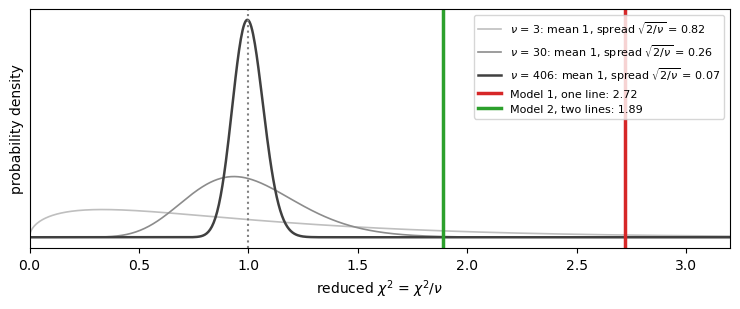

In [9]:
# where a correct model's reduced chi2 would sit, for three values of the degrees of freedom; today's two fits are the vertical lines
plot_reduced_chi2_distribution()


* Model 1 at 2.7 is about 25 standard deviations off - the model is wrong (or the error bars are)
* Model 2 at 1.9 does much better, but it is still far outside the curve, so it is likely we are not using the correct model yet
* $\chi^2$ always falls when we add parameters to a nested model. The question is whether it fell by *more than chance*, and the $\nu = 3$ curve is the one that will answer it


## Diagnostics: the fit, the residuals, the QQ-plot

* the three diagnostics we keep coming back to: the model on the data, the residuals, a QQ-plot of the residuals
* QQ-plot rule from Days 2-3, recalled on Day 7: on the line means the residuals really are Gaussian noise; bending off in the tails means they aren't


In [10]:
# Both fits drawn on the data, their residuals, and QQ-plots of the residuals (a "skip" cell: runs, not a slide)
def plot_fit_diagnostics():
    m1 = 1 + gauss(wave, *res1.x)
    m2 = 1 + gauss(wave, *res2.x[:3]) + gauss(wave, *res2.x[3:])
    r1 = (flux_obs - m1) / noise
    r2 = (flux_obs - m2) / noise
    fig, axs = plt.subplots(2, 2, figsize=(9, 5.4), gridspec_kw={'height_ratios': [1.3, 1]})
    ax = axs[0, 0]
    ax.plot(wave, flux_obs, '.', color='C0', ms=4, alpha=0.7)
    ax.plot(wave, m1, 'C3', lw=1.5, label='Model 1: one line')
    ax.plot(wave, m2, 'C2', lw=1.5, label='Model 2: two lines')
    ax.set_ylabel('normalized flux')
    ax.set_xlabel(r'wavelength [$\AA$]')
    ax.set_title('the fits on the data', fontsize=10)
    ax.legend(fontsize=8)
    ax = axs[0, 1]
    ax.axhline(0, color='0.5', lw=1)
    ax.plot(wave, r1, '.', color='C3', ms=4, label='Model 1')
    ax.plot(wave, r2, '.', color='C2', ms=4, label='Model 2')
    ax.set_ylabel(r'residual / $\sigma$')
    ax.set_xlabel(r'wavelength [$\AA$]')
    ax.set_title('residuals', fontsize=10)
    ax.legend(fontsize=8)
    for ax, r, c, lab in [(axs[1, 0], r1, 'C3', 'Model 1'), (axs[1, 1], r2, 'C2', 'Model 2')]:
        (osm, osr), (sl, ic, _) = stats.probplot(r, dist='norm')
        ax.plot(osm, osr, 'o', ms=3, color=c, alpha=0.7)
        ax.plot(osm, sl * osm + ic, color='0.4', lw=1)
        ax.set_title(f'QQ-plot of residuals, {lab}', fontsize=9)
        ax.set_xlabel('theoretical quantiles')
    plt.tight_layout()
    plt.show()


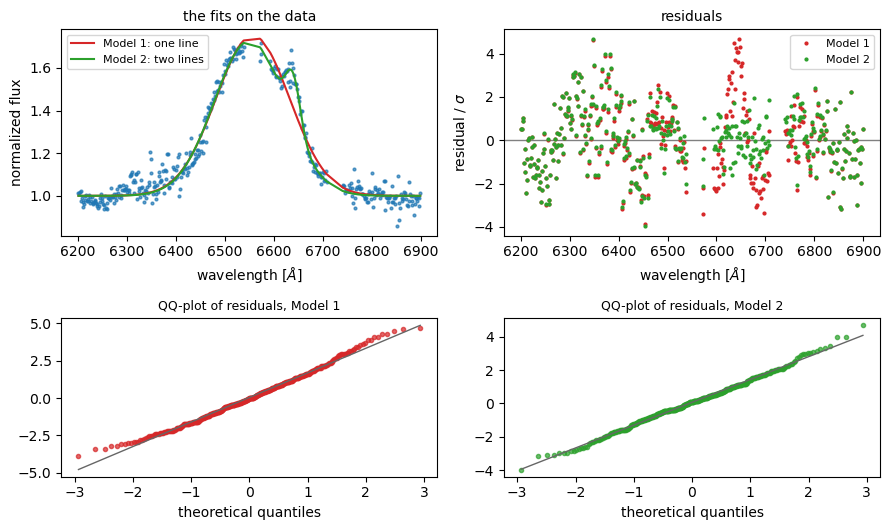

In [11]:
# one-line vs two-line: the fits on the data, the residuals, and their QQ-plots
plot_fit_diagnostics()


* Model 1: a coherent $+4\sigma$ bump in the residuals at the red hump, and a QQ-plot bending off in the tails
* Model 2: the bump is gone; what's left is smaller but still not pure noise, and reduced $\chi^2$ already said so (we'll see why in a few slides)


## Reduced $\chi^2$ on a transit: HD 209458b

<table style="border:none; margin:0 auto;"><tr style="border:none;"><td style="border:none; padding:4px; vertical-align:top;"><img src="images/wittenmyer2005_fig1b_hd209458b_lightcurves.png" alt="Phase-folded transit light curves of the exoplanet HD 209458b from two ground-based telescopes, APT and MLO, each with the same orbital model overplotted: the APT data track the model tightly through the transit, while the MLO data scatter more widely around it" width="440" style="display:block;margin:0 auto;"></td><td style="border:none; padding:4px; vertical-align:top;"><img src="images/wittenmyer2005_fig2b_hd209458b_residuals.png" alt="Normalized residuals, observed minus model divided by uncertainty, for the same two light curves: the APT residuals scatter evenly around zero throughout, while the MLO residuals are wider and lopsided about mid-transit" width="440" style="display:block;margin:0 auto;"></td></tr></table>

<div style="font-size:0.8em; text-align:center; color:#666;">Wittenmyer et al. 2005, ApJ 632, 1157 (arXiv:astro-ph/0504579). HD 209458b is the first planet ever seen to transit (Charbonneau, Brown, Latham &amp; Mayor 2000, ApJ 529, L45; Henry et al. 2000 independently); Charbonneau speaks here Sep 29-30, next slide. Left image: their Fig. 1b, the two ground-based transit light curves with the orbital model. Right image: their Fig. 2b, the normalized residuals.</div>

* one transiting planet, one orbital model, four datasets: two Hubble instruments (STIS, the spectrograph; FGS, the guidance sensors) and two ground telescopes (APT, the Automatic Photometric Telescope at Fairborn; MLO, Mount Laguna Observatory), the two shown here
* reduced $\chi^2$: APT 1.01, STIS 0.95, FGS 1.27, MLO 1.96; the combined fit, 1.36, is dragged up by MLO and FGS
* 0.95 lies inside the spread a correct model gives: $\sqrt{2/\nu}$ with $\nu \approx 550$ for STIS is 0.06, so 0.95 is under one standard deviation low. A value far below 1 usually means the error bars are too big (it is rarely an unusually good fit)
* MLO (lower panel, right): residuals wider and lopsided about mid-transit. That is structure, and their conclusion was a calibration problem, so they kept the model

<div style="font-size:1.35em; line-height:1.45; margin:0.6em 0;">

**Reduced $\chi^2$ tells you something is wrong - it doesn't tell you what. Look at the residuals!**

</div>


## Sep 29 and 30: David Charbonneau (Harvard), the Icko Iben Jr. Distinguished Lecturer

<div style="display:flex; align-items:flex-start; gap:1.4em; margin-top:0.4em;">
<img src="images/speaker_david_charbonneau.jpg" alt="Portrait of astronomer David Charbonneau" style="max-height:400px; border-radius:4px;">
<div>

* he found the planet on the previous slide: HD 209458b was the first exoplanet ever seen to transit, in two full transits in September 1999 (Charbonneau, Brown, Latham &amp; Mayor 2000; Henry et al. 2000 caught a partial one independently)
* public lecture: **"The Terrestrial Worlds of Other Stars"**, JWST's first sniffs of rocky-planet atmospheres and the Habitable Worlds Observatory
* colloquium: "Exoplanets and Stellar Physics", Tuesday Sep 29, 3:45 pm, in this room
* public lecture: Wednesday Sep 30, Lincoln Hall Theater, time in the department email
* Lab 03's transit-depth MLE is the method behind the whole program

</div>
</div>

<div style="font-size:0.7em; color:#666;">Photo: astro.illinois.edu Iben Lecture page, posted for this talk. Charbonneau et al. 2000, ApJ 529, L45; Henry et al. 2000, ApJ 529, L41.</div>


## Von Neumann's elephant

<table style="border:none; margin:0 auto;"><tr style="border:none;"><td style="border:none; padding:4px; vertical-align:top;"><img src="images/polynomial_overfit_chi2.gif" alt="Animation: twelve noisy data points drawn from a sine curve, fit by polynomials of rising degree; the chi-squared printed on the frame falls with every added parameter and reaches exactly zero when a degree-eleven polynomial passes through all twelve points while swinging wildly between them" height="400" style="display:block;margin:0 auto;"></td><td style="border:none; padding:4px; vertical-align:top;"><img src="images/vonneumann_elephant_wiggle.gif" alt="Animation: the outline of an elephant drawn from a four-term complex Fourier series, with a fifth parameter making the trunk wiggle up and down" height="400" style="display:block;margin:0 auto;"></td></tr></table>

<div style="font-size:0.8em; text-align:center; color:#666;">Left: twelve points from a sine, fit by polynomials of degree 0 to 11. Right: Mayer, Khairy &amp; Howard 2010, Am. J. Phys. 78, 648. Quote: von Neumann, as Fermi repeated it to Dyson (Dyson 2004, Nature 427, 297).</div>

* "With four parameters I can fit an elephant, and with five I can make him wiggle his trunk"
* twelve parameters through twelve points: $\chi^2 = 0$! (and nonsense in between them)

<div style="font-size:1.35em; line-height:1.45; margin:0.6em 0;">

**$\chi^2$ always goes down when you add parameters - that isn't evidence for the model.**

</div>


## Occam's razor, with numbers

<p align="center"><img src="images/polynomial_overfit_deg11_still.png" alt="Twelve noisy points from a sine with a degree-eleven polynomial threaded exactly through every point and swinging far outside the data between them; chi-squared equals zero" style="display:block;margin:0 auto;max-height:300px"></p>

* Occam's razor: of two models that explain the data equally well, keep the one with fewer assumptions
* every free parameter is an assumption we get to tune (a subjective choice!), so "equally well" has to be judged after we account for them
* two ways to penalize extra parameters today: the **likelihood-ratio test** (next) for nested models, **AIC/BIC** (after that) for any two
* i.e. keep a parameter only if it improves the fit by more than chance would (the elephant's fifth parameter doesn't)


## The likelihood-ratio test

Suppose the simpler model is the true one: the **null hypothesis**, the extra parameters add nothing real. Then $\Delta\chi^2 = \chi^2_1 - \chi^2_2 = -2\ln(\mathcal{L}_1/\mathcal{L}_2)$, the log of the likelihood ratio, follows a $\chi^2$ distribution with $\Delta k$ degrees of freedom, where $\Delta k$ is the number of *extra* parameters (a different count from the $N - k$ above: $\Delta k = 3$ here, so it's the wide $\nu = 3$ curve from two slides back, now on an unscaled $\Delta\chi^2$ axis).

<div style="font-size:1.35em; line-height:1.45; margin:0.6em 0;">

**Let's assume the simpler model is true. Then the question is how often noise alone gives a $\Delta\chi^2$ this big.**

</div>


## The p-value

* the p-value: the probability that noise alone, under the null, would produce a $\Delta\chi^2$ at least this large. Small means the second component is hard to explain away
* same logic as the KS test from Day 4, recapped on Day 5: compute a statistic, then ask how often chance alone would produce one at least this big


In [12]:
# Likelihood-ratio test: is the chi2 improvement bigger than 3 extra free parameters would buy by chance?
delta_chi2 = res1.fun - res2.fun
extra_params = 3
p_value = stats.chi2.sf(delta_chi2, df=extra_params)
log10_p = stats.chi2.logsf(delta_chi2, df=extra_params) / np.log(10)
print(f"Delta chi2 = {delta_chi2:.1f} for {extra_params} extra parameters")
print(f"p-value (null: one component is enough) = 10^{log10_p:.0f}")


Delta chi2 = 344.7 for 3 extra parameters
p-value (null: one component is enough) = 10^-74


In [13]:
# the improvement, against what three extra parameters would buy by chance
print(f"Delta chi2 = {delta_chi2:.1f} for {extra_params} extra parameters")
print(f"p-value (null: one component is enough) = 10^{log10_p:.0f}")


Delta chi2 = 344.7 for 3 extra parameters
p-value (null: one component is enough) = 10^-74


In [14]:
# The chi2 distribution the test compares against, with the observed Delta chi2 marked (a "skip" cell)
def plot_lrt():
    fig, ax = plt.subplots(figsize=(7, 2.6))
    x = np.linspace(0, 25, 400)
    ax.plot(x, stats.chi2.pdf(x, extra_params), color='0.3', label=fr'$\chi^2$ distribution, {extra_params} degrees of freedom')
    x95 = stats.chi2.ppf(0.95, extra_params)
    ax.fill_between(x, stats.chi2.pdf(x, extra_params), where=x > x95, color='C3', alpha=0.3, label='the 5% tail')
    ax.annotate(fr'observed $\Delta\chi^2$ = {delta_chi2:.0f}, off the chart; p = $10^{{{log10_p:.0f}}}$',
                xy=(24.5, 0.01), xytext=(9, 0.12), fontsize=9, arrowprops=dict(arrowstyle='->'))
    ax.set_xlabel(r'$\Delta\chi^2$')
    ax.set_yticks([])
    ax.legend(fontsize=8, loc='upper right')
    plt.tight_layout()
    plt.show()


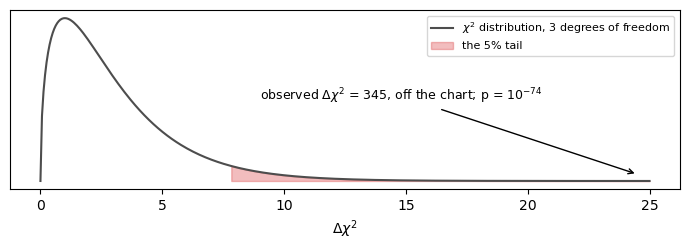

In [15]:
# what chance alone would buy with three extra parameters, and where our improvement sits
plot_lrt()


* tiny p: noise essentially never gets you this much from three extra parameters, so the second component is real (whatever its exact shape)
* caveat: the null puts $A_2$ at the edge of its range, and there the second line's position and width mean nothing, so the $\chi^2$ reference distribution above is not quite the right one. Here the improvement is so large that the conclusion survives; in marginal cases, calibrate by simulation (Protassov et al. 2002, ApJ 571, 545)


## AIC and BIC

The likelihood-ratio test only works if the models are nested. When they aren't (a power law vs. a broken power law, say), it becomes useful to define an **information criterion**:

$$\text{AIC} = -2\ln\mathcal{L}_{\textrm{max}} + 2k \qquad \text{BIC} = -2\ln\mathcal{L}_{\textrm{max}} + k\ln N$$

* Akaike and Bayesian information criteria: $k$ free parameters, $N$ data points. we want the model with the lower value; BIC penalizes parameters harder once $\ln N > 2$, i.e. $N \gtrsim 8$


## AIC and BIC for today's fits

* with fixed, known $\sigma$, a fitted $\chi^2$ is $-2\ln\mathcal{L}_{\textrm{max}}$ up to a constant, so today's fits plug straight in (Tuesday's fitted $\sigma_{\textrm{int}}$ is the exception)
* only *differences* mean anything. A common ladder for $\Delta$BIC, the one we'll apply to a real CO line in Tuesday's recap: 0-2 weak, 2-6 positive, 6-10 strong, above 10 very strong (Kass &amp; Raftery 1995; these are conventions, not theorems)


In [16]:
# AIC and BIC for the one- and two-component fits (chi2 here doubles as -2 ln L up to a constant)
k1, k2 = 3, 6
N = n_data
aic1, aic2 = res1.fun + 2*k1, res2.fun + 2*k2
bic1, bic2 = res1.fun + k1*np.log(N), res2.fun + k2*np.log(N)
print(f"AIC: one-line {aic1:.1f}  vs  two-line {aic2:.1f}  (lower wins: {'two' if aic2<aic1 else 'one'})")
print(f"BIC: one-line {bic1:.1f}  vs  two-line {bic2:.1f}  (lower wins: {'two' if bic2<bic1 else 'one'})")


AIC: one-line 1118.3  vs  two-line 779.6  (lower wins: two)
BIC: one-line 1130.4  vs  two-line 803.7  (lower wins: two)


In [17]:
# AIC and BIC for the one- and two-component fits
print(f"AIC: one-line {aic1:.1f}  vs  two-line {aic2:.1f}  (lower wins: {'two' if aic2<aic1 else 'one'})")
print(f"BIC: one-line {bic1:.1f}  vs  two-line {bic2:.1f}  (lower wins: {'two' if bic2<bic1 else 'one'})")


AIC: one-line 1118.3  vs  two-line 779.6  (lower wins: two)
BIC: one-line 1130.4  vs  two-line 803.7  (lower wins: two)


In [18]:
# chi2, AIC and BIC as the number of Gaussian components grows (a "skip" cell)
def chi2_components(p, k):
    model = 1 + sum(gauss(wave, *p[3*j:3*j+3]) for j in range(k))
    return np.sum((flux_obs - model)**2 / noise**2)

fits_k = {}

def fit_components_sequence(kmax=3):
    # start each fit from the previous best fit plus a small new line at the largest residual
    fits = {1: res1.x, 2: res2.x}
    for k in range(3, kmax + 1):
        prev = fits[k - 1]
        model = 1 + sum(gauss(wave, *prev[3*j:3*j+3]) for j in range(k - 1))
        where = wave[np.argmax(np.abs(flux_obs - model))]
        x0 = list(prev) + [0.05, where, 20.0]
        r = minimize(chi2_components, x0=x0, args=(k,), method='Nelder-Mead',
                     options={'xatol': 1e-8, 'fatol': 1e-8, 'maxiter': 40000})
        fits[k] = r.x
    fits_k.update(fits)
    return {k: chi2_components(x, k) for k, x in fits.items()}

def plot_criteria_vs_k():
    chi2s = fit_components_sequence()
    ks = np.array(sorted(chi2s))
    c2 = np.array([chi2s[k] for k in ks])
    aics = c2 + 2 * 3 * ks
    bics = c2 + 3 * ks * np.log(n_data)
    fig, axs = plt.subplots(1, 2, figsize=(8, 2.8))
    axs[0].plot(ks, c2, 'o-', color='0.3')
    axs[0].set_yscale('log')
    axs[0].set_xlabel('number of Gaussian components')
    axs[0].set_ylabel(r'$\chi^2$ (log scale)')
    axs[0].set_xticks(ks)
    axs[1].plot(ks, aics, 'o-', color='C0', label='AIC')
    axs[1].plot(ks, bics, 's-', color='C3', label='BIC')
    axs[1].set_ylim(min(aics.min(), bics.min()) - 15, max(aics[1:].max(), bics[1:].max()) + 40)
    axs[1].set_xlabel('number of Gaussian components')
    axs[1].set_xticks(ks)
    axs[1].legend(fontsize=8)
    plt.tight_layout()
    plt.show()


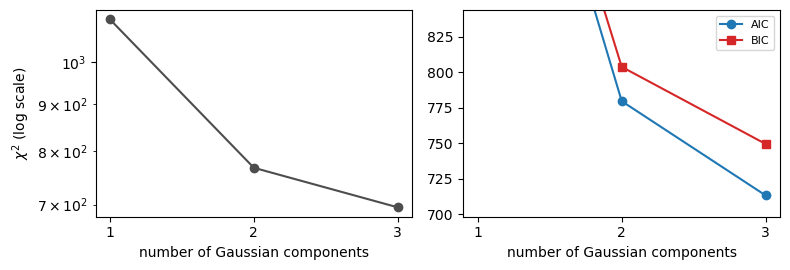

In [19]:
# chi2 keeps falling as we add Gaussians, and here AIC and BIC keep falling too: the third one is fitting the wrong thing
plot_criteria_vs_k()


* both prefer two Gaussians over one by hundreds; they usually agree when the evidence is this strong
* a third Gaussian lowers them again, but it is broad ($w \approx 14$ &Aring;) and lies at 6312 &Aring;, the blue edge: it's fitting the plateau the next slide explains, and a sum of Gaussians is the wrong model, so AIC and BIC keep dropping as we add more
* none of this replaces looking at the residuals by eye. The regression unit starting Sep 22 comes back to that

<div style="font-size:1.35em; line-height:1.45; margin:0.6em 0;">

**AIC and BIC pick the best of the models you gave them. They don't tell you if any of them is right.**

</div>


## What is that blue wing?

* two Gaussians leave a broad plateau on the blue side, 6300 to 6400 &Aring;: 100 &Aring; of pixels $+2\sigma$ above the model, out to $-12{,}000$ km/s
* it isn't a narrow line: [O I] 6300 and 6364 (forbidden lines of neutral oxygen) are in there, but they are a few &Aring; wide; 6300 is in our "continuum" window and 6364 is unmasked in the fit, and neither is 100 &Aring; of plateau
* the dotted red curve is the third Gaussian from the last slide: a broad bump laid over the plateau, which is why AIC and BIC kept dropping


In [20]:
# The blue wing of the two-Gaussian fit, with the three-Gaussian fit and its third component, and the [O I] lines marked (a "skip" cell)
def plot_blue_wing():
    m2 = 1 + gauss(wave_all, *res2.x[:3]) + gauss(wave_all, *res2.x[3:])
    p3 = fits_k[3]
    m3 = 1 + sum(gauss(wave_all, *p3[3*j:3*j+3]) for j in range(3))
    third = gauss(wave_all, *p3[6:9])
    fig, axs = plt.subplots(2, 1, figsize=(7, 4), sharex=True, gridspec_kw={'height_ratios': [1.6, 1]})
    axs[0].errorbar(wave_all, flux_all, yerr=err_all, fmt='.', color='C0', ms=3, alpha=0.6, elinewidth=0.5)
    axs[0].plot(wave_all, m2, 'C2', lw=1.5, label='Model 2: two Gaussians')
    axs[0].plot(wave_all, m3, 'C3', lw=1.2, ls='--', label='three Gaussians')
    axs[0].plot(wave_all, 1 + third, 'C3', lw=1.8, ls=':', label=f'the third one alone: {p3[7]:.0f} $\\AA$, w = {p3[8]:.0f} $\\AA$')
    axs[1].axhline(0, color='0.5', lw=0.8)
    axs[1].plot(wave_all, (flux_all - m2) / err_all, '.', color='C2', ms=3)
    for l, lab in ((6300.3, '[O I] 6300'), (6363.8, '[O I] 6364')):
        axs[0].axvline(l, color='C1', ls='--', lw=1)
        axs[0].text(l + 2, 1.75, lab, color='C1', fontsize=8)
        axs[1].axvline(l, color='C1', ls='--', lw=1)
    axs[0].set_xlim(6250, 6560)
    axs[0].set_ylim(0.9, 1.9)
    axs[1].set_ylim(-4, 5)
    axs[0].set_ylabel('flux / continuum')
    axs[1].set_ylabel(r'residual / $\sigma$')
    axs[1].set_xlabel(r'rest wavelength [$\AA$]')
    axs[0].legend(fontsize=8, loc='lower right')
    plt.tight_layout()
    plt.show()


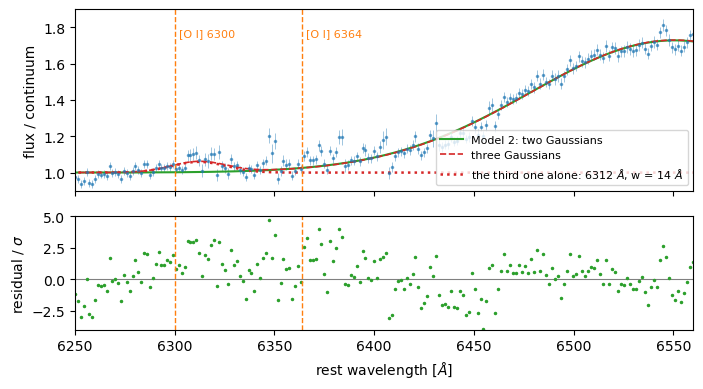

In [21]:
# the blue side of the line: a broad plateau the two Gaussians never reach; the third Gaussian (dotted) is a broad bump laid over it, not the narrow [O I] lines
plot_blue_wing()


* the disk-video slide told us why the blue side is brighter (Doppler boosting); the next two slides show why it is also stretched, and why a disk line is not a sum of Gaussians


## The paper's fits

<img src="images/strateva2003_fig3ab_halpha_gaussian_fits_crop.png" alt="Two panels of SDSS AGN H-alpha profiles in radial velocity, each with the sum-of-Gaussians fit drawn through the data, the individual broad Gaussians dashed above the spectrum, and the two peak positions marked; the right panel also has a central narrow H-alpha spike and a small bump at minus 12,000 km/s" style="display:block;margin:0 auto;max-height:300px">

<div style="font-size:0.8em; text-align:center; color:#666;">Strateva et al. 2003, AJ 126, 1720 (arXiv:astro-ph/0307357), Fig. 3a and 3b: the narrow lines ([O I], [N II], [S II], narrow H&alpha;) are fit and subtracted; the disk line is the sum of the dashed broad Gaussians. The bump at &minus;12,000 km/s in the right panel is [O I] 6300, the same feature we have at our blue edge.</div>

* fit the narrow lines explicitly, [O I] 6300/6364 included, instead of hiding them in the continuum
* then "two to four Gaussians for the asymmetric broad component. Most AGN line-profiles require more than two broad Gaussians for a good fit"
* some objects also need a "broad central H$\alpha$" on top, from a separate region, as in the prototype Arp 102B


## The paper's disk model

$$F_X \propto \cos i \int_{\xi_1}^{\xi_2}\!\!\int_{-\pi/2}^{\pi/2} \xi^{\,1-q}\, D^3\, g(D)\, \exp\!\left[-\frac{(1+X-D)^2\,\nu_0^2}{2\sigma^2 D^2}\right] d\phi\, d\xi, \qquad D = \frac{\sqrt{1-3/\xi}}{1+\xi^{-1/2}\sin i \sin\phi}$$

<div style="font-size:0.8em; text-align:center; color:#666;">Strateva et al. 2003, Section 5, eqns. 5-9 (the Chen &amp; Halpern 1989 circular disk); $\xi = r/R_G$ is the radius in gravitational radii ($R_G = GM/c^2$), $\phi$ the azimuth around the disk, $\nu_0$ the line's rest frequency and $X = \nu/\nu_0 - 1$ the velocity, $g(D)$ a correction for light bent by the black hole.</div>

* every piece of this is physics: $\xi^{-q}$ is how bright the ring is at each radius (the emissivity; the extra $\xi$ in the integrand is the area element), $D$ is the Doppler shift and beaming of gas orbiting at $\xi$, and the Gaussian is turbulence in the gas
* so you fit five numbers - the inner and outer edge of the ring, $\xi_1$ and $\xi_2$, the tilt $i$, how fast the emissivity falls off, $q$, and the turbulent width $\sigma$. One fewer than our two Gaussians, but now you can ask what each one is telling you
* push $\xi_1$ inward and the blue peak dominates; make the emissivity fall faster than $\xi^{-2}$ and the blue wing gets less steep (Strateva's Section 5.4). That extended wing is what our Gaussians couldn't fit


## Colloquium, Tue Sep 22, 3:45 pm, this room: Charlotte Ward (Penn State)

<div style="display:flex; align-items:flex-start; gap:1.4em; margin-top:0.4em;">
<img src="images/speaker_charlotte_ward.jpg" alt="Portrait of astronomer Charlotte Ward" style="max-height:400px; border-radius:4px;">
<div>

* **"Better Together: Combining the Strengths of Rubin, Euclid, and Roman for Time-domain Science and Cosmology"**
* her group studies disk-emitting and changing-look AGN
* today's line, at survey scale: Ward et al. 2024, "Panic at the ISCO", found 250 double-peaked emitters among the variable AGN in ZTF (the Zwicky Transient Facility survey), about one in five, and half of them change the red/blue peak ratio over 10 to 20 years - spiral arms and hot spots on the disk, the same thing NGC 1097 showed you
* refreshments 3:30 pm, Astronomy 222. Colloquia are every Tuesday at 3:45 in this classroom. Go

</div>
</div>

<div style="font-size:0.7em; color:#666;">Photo: charlotteaward.github.io, used to advertise her own talk. Ward et al. 2024, ApJ 961, 172. Listing: astro.illinois.edu/news-events/astrophysics-colloquium.</div>


## In-class exercise: one line, two, three, or the wrong model?

`lecture/04/inclass_exercise_day8.ipynb`: a second double-peaked AGN from the same paper, SDSS J233254.46+151305.4. Loading, normalizing and masking are done for you. Pairs, 10 minutes, then two pairs defend.

* you cannot do this by hand in 10 minutes. **Copilot writes every line; you write the prompts and check what comes back**
* Q1: one prompt to plot, fit 1, 2, 3 Gaussians, print $\chi^2$, dof, reduced $\chi^2$. Check the dof
* Q2: three starting guesses that differ in kind. Check whether they agree
* Q3: residuals over $\sigma$ and a QQ-plot. Check what it divided by
* Q4: $\Delta\chi^2$, $\log_{10} p$, AIC, BIC. Check the test's dof is 3, and that it reports $\log_{10} p$, not a rounded $p$
* Q5: defend it in two lines, and name the one thing Copilot got wrong


## Wrapping up model comparison

* reduced $\chi^2 \gg 1$: the model is missing something, or the error bars are wrong. Then look at the residuals to find out what
* more parameters always lower $\chi^2$ (nested models); the question is whether by more than chance. Occam's razor, with numbers
* nested models: the likelihood-ratio test, $\Delta\chi^2$ against a $\chi^2$ distribution with $\Delta k$ degrees of freedom
* any two models: AIC and BIC, lower is better, BIC penalizes complexity harder. They pick the best of the models you offered - and our two Gaussians were the wrong model; the residuals said so before the criteria did
* next week: regression, Sep 22/24. Then Sep 29: real prior information, answers that aren't a single point, and the Bayes factor, the Bayesian cousin of today's tests


## Before you go

* **Lab 03** is posted today, due Wed Sep 23 by Noon (fork then PR, as always). Every due date for the term is now in `ASSIGNMENTS.md` at the top of the repo
* Nothing from today is collected.
* Colloquium next week (Sep 22): Charlotte Ward (PSU), "Better Together: Combining the Strengths of Rubin, Euclid, and Roman for Time-domain Science and Cosmology"
* EXTRA notebook, for reading: `lecture/04/extra_fisher_in_practice.ipynb`. Fisher forecasts: how well an experiment *could* do before the data exist, promised on Day 6
* Sep 22/24: regression - ordinary least squares, generalized least squares, and when a generative model beats both. Sep 29: priors, and the Bayes factor
